In [1]:
!python3 -m pip install pandas numpy scikit-learn matplotlib seaborn tabulate

In [2]:
import pandas as pd
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df_hierarchy_bws = pd.read_csv("./hierarchy_bw_test.csv")
df_hierarchy_bws.columns = map(lambda x: x.strip(), df_hierarchy_bws.columns)

In [25]:
# As there are some duplicates due to testing multiple times, taking the max bandwidth for a particular Window_Size
df_hierarchy_bws = (
    df_hierarchy_bws
    .groupby("Window_Size", as_index=False)
    .agg(**{
        "Bandwidth": pd.NamedAgg(column="Bandwidth", aggfunc=np.max),
    })
    .sort_values("Window_Size", ascending=True)
)
df_hierarchy_bws["id"] = np.arange(len(df_hierarchy_bws))
df_hierarchy_bws

,Window_Size,Bandwidth,id
0,4066,130.582523,0
1,4076,129.981020,1
2,4086,129.787260,2
3,4096,131.942997,3
4,4106,130.541517,4
...,...,...,...
267,1073741814,21.166771,267
268,1073741824,21.512669,268
269,1073741834,21.517677,269
270,1073741844,21.009852,270


<Axes: xlabel='id', ylabel='Bandwidth'>

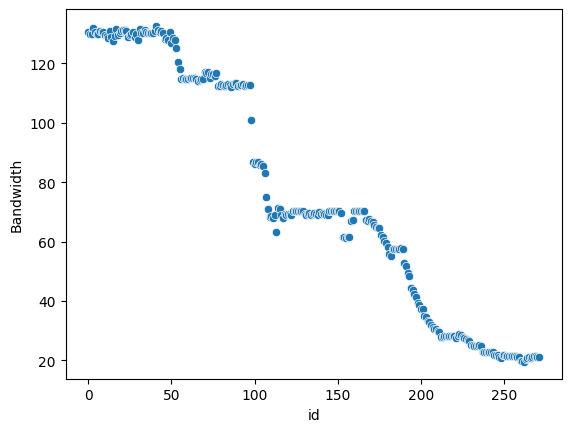

In [32]:
sns.scatterplot(data=df_hierarchy_bws, x="id", y="Bandwidth")

<Axes: xlabel='Bandwidth', ylabel='Bandwidth'>

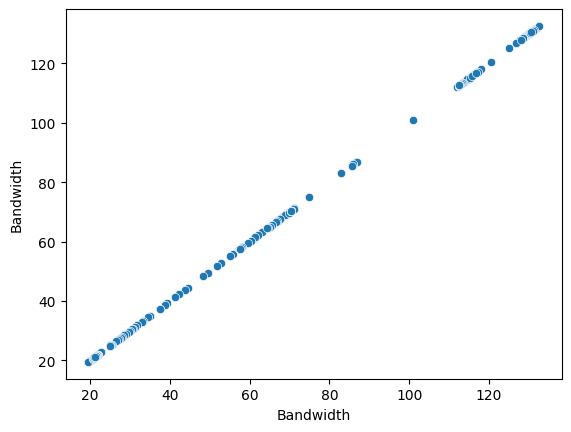

In [33]:
sns.scatterplot(data=df_hierarchy_bws, x="Bandwidth", y="Bandwidth")

In [34]:
# Visually, we can see 5 clusters

In [35]:
kmeans_clf = sk.cluster.KMeans(n_clusters=5, random_state=69)
df = pd.DataFrame()
df["x"] = df_hierarchy_bws["Bandwidth"].values
df["y"] = df_hierarchy_bws["Bandwidth"].values
df["cluster"] = kmeans_clf.fit_predict(df)
df["Window_Size"] = df_hierarchy_bws["Window_Size"].values
centers = kmeans_clf.cluster_centers_
centers

array([[114.03881978, 114.03881978],
       [ 44.22523794,  44.22523794],
       [ 68.78209753,  68.78209753],
       [129.87681063, 129.87681063],
       [ 24.73489199,  24.73489199]])

In [36]:
df

,x,y,cluster,Window_Size
0,130.582523,130.582523,3,4066
1,129.981020,129.981020,3,4076
2,129.787260,129.787260,3,4086
3,131.942997,131.942997,3,4096
4,130.541517,130.541517,3,4106
...,...,...,...,...
267,21.166771,21.166771,4,1073741814
268,21.512669,21.512669,4,1073741824
269,21.517677,21.517677,4,1073741834
270,21.009852,21.009852,4,1073741844


<Axes: xlabel='x', ylabel='y'>

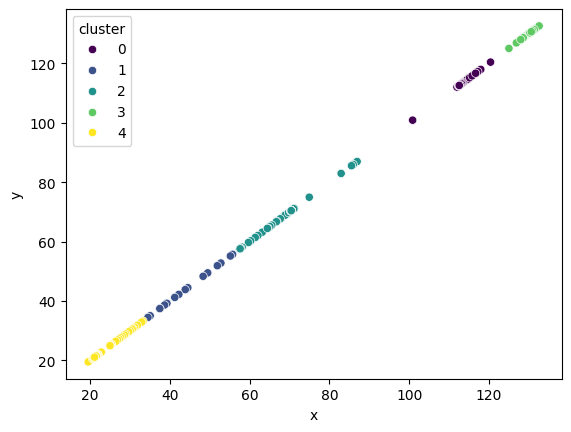

In [37]:
sns.scatterplot(data=df, x='x', y='y', hue='cluster', palette='viridis', legend='full', alpha=1.0)

In [38]:
print(
    df
    .groupby("cluster")
    .agg(**{
        "min_Window_Size": pd.NamedAgg(column="Window_Size", aggfunc=lambda x: np.min(x).astype(np.int32)),
        "max_Window_Size": pd.NamedAgg(column="Window_Size", aggfunc=lambda x: np.max(x).astype(np.int32)),
        "avg_bw"         : pd.NamedAgg(column="x"          , aggfunc=lambda x: np.round(np.average(x), 2)),
    })
    .sort_values(by=["avg_bw"], ascending=False)
    .to_markdown(floatfmt=".2f")
)

|   cluster |   min_Window_Size |   max_Window_Size |   avg_bw |
|----------:|------------------:|------------------:|---------:|
|         3 |           4066.00 |          33792.00 |   129.88 |
|         0 |          34816.00 |         196608.00 |   114.04 |
|         2 |         262114.00 |        8388638.00 |    68.78 |
|         1 |        7929856.00 |       11862016.00 |    44.23 |
|         4 |       12124160.00 |     1073741854.00 |    24.73 |
